In [1]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2026-03-30 17:05:42--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 72.247.96.197, 2600:1406:5400:2ac::317f, 2600:1406:5400:2ae::317f
Connecting to download.microsoft.com (download.microsoft.com)|72.247.96.197|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   124MB/s    in 7.1s    

2026-03-30 17:05:49 (111 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [2]:
!unzip kagglecatsanddogs_5340.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

In [3]:
import os
import shutil
import random
from PIL import Image

# Install Pillow if not already installed to handle image operations
!pip install Pillow --quiet

# Define paths
original_cats_dir = 'PetImages/Cat'
original_dogs_dir = 'PetImages/Dog'
base_dir = 'data'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Create base directory
os.makedirs(base_dir, exist_ok=True)

# Create train, validation, test directories with subfolders for cats and dogs
for dir_path in [train_dir, validation_dir, test_dir]:
    os.makedirs(os.path.join(dir_path, 'cats'), exist_ok=True)
    os.makedirs(os.path.join(dir_path, 'dogs'), exist_ok=True)

# Function to filter out corrupted images
def is_valid_image(filepath):
    try:
        # Check if file is empty
        if os.path.getsize(filepath) == 0:
            return False
        img = Image.open(filepath)
        img.verify() # Verify that it is, in fact, an image
        img.close() # Close the image to release file handle
        return True
    except (IOError, SyntaxError, FileNotFoundError) as e:
        # print(f"Bad image or file not found: {filepath}, {e}") # Optional: uncomment to see bad files
        return False

print("Scanning for valid cat images...")
all_cat_files = []
for f in os.listdir(original_cats_dir):
    filepath = os.path.join(original_cats_dir, f)
    if f.lower().endswith(('.png', '.jpg', '.jpeg')) and is_valid_image(filepath):
        all_cat_files.append(filepath)

print("Scanning for valid dog images...")
all_dog_files = []
for f in os.listdir(original_dogs_dir):
    filepath = os.path.join(original_dogs_dir, f)
    if f.lower().endswith(('.png', '.jpg', '.jpeg')) and is_valid_image(filepath):
        all_dog_files.append(filepath)

# Shuffle files for random splitting
random.seed(42) # for reproducibility
random.shuffle(all_cat_files)
random.shuffle(all_dog_files)

# Define split ratios (e.g., 70% train, 15% validation, 15% test)
train_split_ratio = 0.7
validation_split_ratio = 0.15

# Calculate split indices for cats
num_cats = len(all_cat_files)
train_cats_count = int(num_cats * train_split_ratio)
validation_cats_count = int(num_cats * validation_split_ratio)

train_cat_files = all_cat_files[:train_cats_count]
validation_cat_files = all_cat_files[train_cats_count : train_cats_count + validation_cats_count]
test_cat_files = all_cat_files[train_cats_count + validation_cats_count:]

# Calculate split indices for dogs
num_dogs = len(all_dog_files)
train_dogs_count = int(num_dogs * train_split_ratio)
validation_dogs_count = int(num_dogs * validation_split_ratio)

train_dog_files = all_dog_files[:train_dogs_count]
validation_dog_files = all_dog_files[train_dogs_count : train_dogs_count + validation_dogs_count]
test_dog_files = all_dog_files[train_dogs_count + validation_dogs_count:]

# Function to copy files
def copy_files(file_list, destination_dir):
    for f_path in file_list:
        try:
            filename = os.path.basename(f_path)
            dest_path = os.path.join(destination_dir, filename)
            shutil.copyfile(f_path, dest_path)
        except Exception as e:
            print(f"Error copying {f_path} to {destination_dir}: {e}")

print("Copying cat images to train, validation, and test directories...")
copy_files(train_cat_files, os.path.join(train_dir, 'cats'))
copy_files(validation_cat_files, os.path.join(validation_dir, 'cats'))
copy_files(test_cat_files, os.path.join(test_dir, 'cats'))

print("Copying dog images to train, validation, and test directories...")
copy_files(train_dog_files, os.path.join(train_dir, 'dogs'))
copy_files(validation_dog_files, os.path.join(validation_dir, 'dogs'))
copy_files(test_dog_files, os.path.join(test_dir, 'dogs'))

print("\nData organization complete.")
print(f"Total valid cat images found: {num_cats}")
print(f"Total valid dog images found: {num_dogs}")
print("-" * 30)
print(f"Train set: {len(train_cat_files)} cats, {len(train_dog_files)} dogs")
print(f"Validation set: {len(validation_cat_files)} cats, {len(validation_dog_files)} dogs")
print(f"Test set: {len(test_cat_files)} cats, {len(test_dog_files)} dogs")
print("-" * 30)

# Optionally, remove the original PetImages folder to save space after copying
# shutil.rmtree('PetImages', ignore_errors=True)
# print("Removed original PetImages directory to save space.")

Scanning for valid cat images...
Scanning for valid dog images...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Copying cat images to train, validation, and test directories...
Copying dog images to train, validation, and test directories...

Data organization complete.
Total valid cat images found: 12499
Total valid dog images found: 12499
------------------------------
Train set: 8749 cats, 8749 dogs
Validation set: 1874 cats, 1874 dogs
Test set: 1876 cats, 1876 dogs
------------------------------


Thisi

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau # Import callbacks
import matplotlib.pyplot as plt
import numpy as np
import os

### Data Processing with `ImageDataGenerator`

Now, let's load and preprocess the images using `ImageDataGenerator`. This will handle resizing, normalization, and data augmentation for the training set.

In [5]:
# Define image dimensions and batch size
IMAGE_SIZE = (150, 150) # Smaller size for MobileNetV2
BATCH_SIZE = 32

# Define paths to your data directories
train_dir = 'data/train'
validation_dir = 'data/validation'
test_dir = 'data/test'

# Data Augmentation and Preprocessing for Training data
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=40,          # Random rotations
    width_shift_range=0.2,      # Random horizontal shifts
    height_shift_range=0.2,     # Random vertical shifts
    shear_range=0.2,            # Random shearing transformations
    zoom_range=0.2,             # Random zooms
    horizontal_flip=True,       # Random horizontal flips
    fill_mode='nearest'         # Strategy for filling in new pixels
)

# Preprocessing for Validation and Test data (only rescale)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' for 2 classes (cat/dog)
)

validation_generator = validation_test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = validation_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for evaluation
)

print("Data generators created successfully.")

Found 17498 images belonging to 2 classes.
Found 3748 images belonging to 2 classes.
Found 3752 images belonging to 2 classes.
Data generators created successfully.


### Visualize Sample Images

Let's visualize some augmented images from the training set to ensure the `ImageDataGenerator` is working as expected.

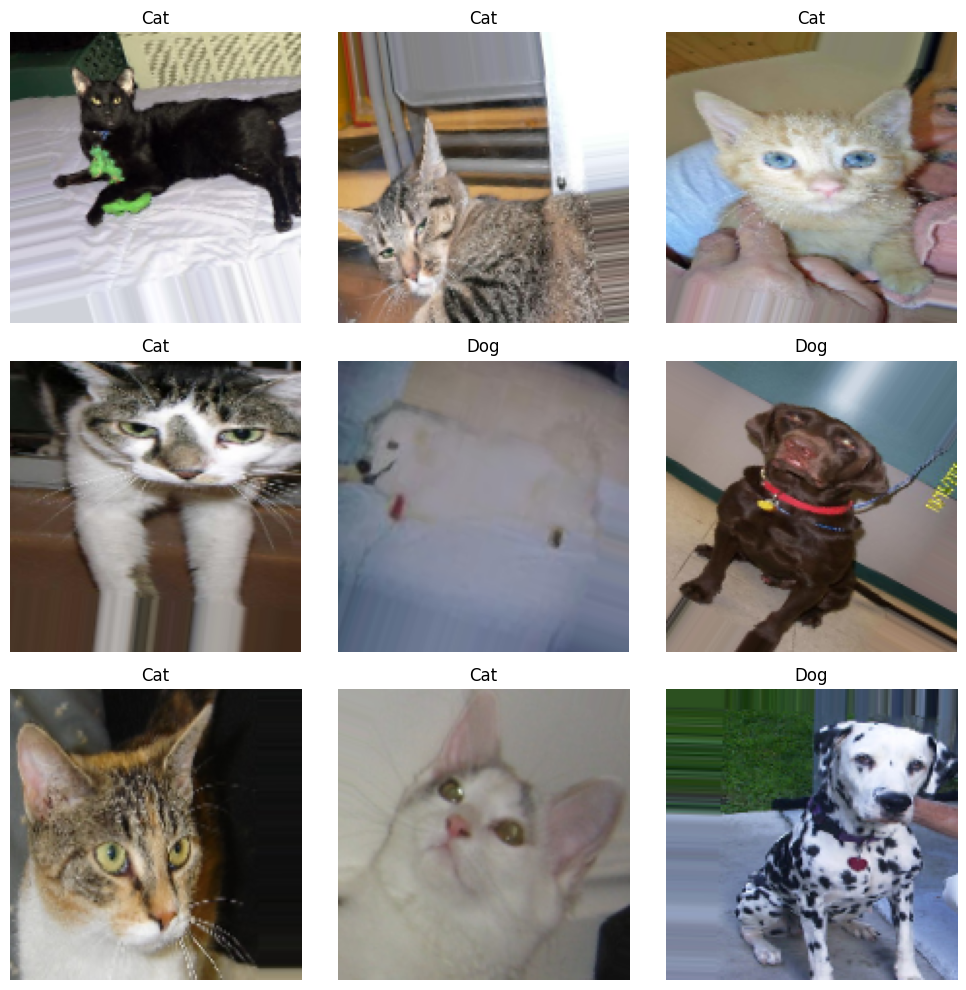

In [6]:
# Get a batch of training images and labels
images, labels = next(train_generator)

fig = plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    if labels[i] == 0:
        plt.title("Cat")
    else:
        plt.title("Dog")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Load Pretrained Model and Freeze Layers

Now, we'll load the `MobileNetV2` model without its top (classification) layers and freeze its weights to prevent them from being updated during training.

In [7]:
# Load MobileNetV2 pre-trained on ImageNet, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# Freeze the base model layers
base_model.trainable = False

print("MobileNetV2 base model loaded and layers frozen.")

/tmp/ipykernel_4621/1899566248.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base model loaded and layers frozen.


### Add Custom Classification Head

We'll add our own `Dense` layers on top of the frozen base model for binary classification, including a `Dropout` layer for regularization.

In [8]:
# Create a new model on top
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

model = Model(inputs=base_model.input, outputs=predictions)

print("Custom classification head added.")

Custom classification head added.


### Compile the Model

Finally, compile the model using the Adam optimizer, `binary_crossentropy` loss, and `accuracy` as the metric.

### Train the Model

We will now train the transfer learning model using the image data generators. The training process will be monitored using the validation data.

In [9]:
EPOCHS = 10

# Define image dimensions and batch size
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Define paths to your data directories
train_dir = 'data/train'
validation_dir = 'data/validation'
test_dir = 'data/test'

# Data Augmentation and Preprocessing for Training data
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normalize pixel values to [0, 1]
    rotation_range=40,          # Random rotations
    width_shift_range=0.2,      # Random horizontal shifts
    height_shift_range=0.2,     # Random vertical shifts
    shear_range=0.2,            # Random shearing transformations
    zoom_range=0.2,             # Random zooms
    horizontal_flip=True,       # Random horizontal flips
    fill_mode='nearest'         # Strategy for filling in new pixels
)

# Preprocessing for Validation and Test data (only rescale)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' for 2 classes (cat/dog)
)

validation_generator = validation_test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = validation_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for evaluation
)

print("Data generators created successfully.")

# Load MobileNetV2 pre-trained on ImageNet, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# Freeze the base model layers
base_model.trainable = False

print("MobileNetV2 base model loaded and layers frozen.")

# Create a new model on top
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

model = Model(inputs=base_model.input, outputs=predictions)
print("Custom classification head added.")

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully.")
model.summary()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.00001)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, model_checkpoint, reduce_lr] # Add callbacks here
)

print("Model training complete.")

Found 17498 images belonging to 2 classes.
Found 3748 images belonging to 2 classes.
Found 3752 images belonging to 2 classes.
Data generators created successfully.


/tmp/ipykernel_4621/2853393672.py:53: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))


MobileNetV2 base model loaded and layers frozen.
Custom classification head added.
Model compiled successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

...

 Trainable params: 4,096,257 (15.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 167s 269ms/step - accuracy: 0.9051 - loss: 0.2278 - val_accuracy: 0.9527 - val_loss: 0.1178 - learning_rate: 1.0000e-04
Epoch 2/10
  1/546 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9062 - loss: 0.2586

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9062 - loss: 0.2586 - val_accuracy: 0.9511 - val_loss: 0.1231 - learning_rate: 1.0000e-04
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 164s 236ms/step - accuracy: 0.9206 - loss: 0.1807 - val_accuracy: 0.9578 - val_loss: 0.1086 - learning_rate: 1.0000e-04
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9688 - loss: 0.1117 - val_accuracy: 0.9551 - val_loss: 0.1107 - learning_rate: 1.0000e-04
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 126s 230ms/step - accuracy: 0.9254 - loss: 0.1765 - val_accuracy: 0.9591 - val_loss: 0.0943 - learning_rate: 1.0000e-04
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9062 - loss: 0.1668 - val_accuracy: 0.9583 - val_loss: 0.0947 - learning_rate: 1.0000e-04
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 128s 234ms/step - accuracy: 0.9310 - loss: 0.1708 - val_accuracy: 0.9594 - val_loss: 0.0998 - learning_rate: 1.0000e-04
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accur

### Plot Training and Validation Curves

Let's visualize the training and validation accuracy and loss to assess the model's performance and identify potential overfitting.

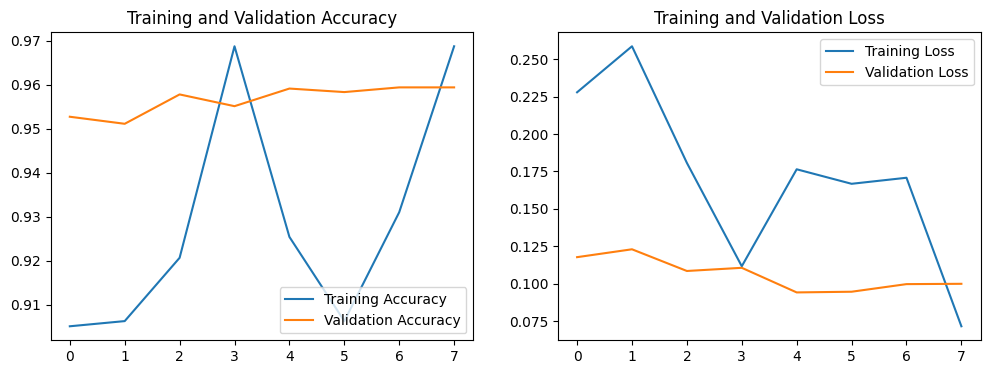

In [10]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Train the Model

We will now train the transfer learning model using the image data generators. The training process will be monitored using the validation data.

In [11]:
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model training complete.")

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 126s 230ms/step - accuracy: 0.9331 - loss: 0.1594 - val_accuracy: 0.9581 - val_loss: 0.1003
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9375 - loss: 0.0836 - val_accuracy: 0.9578 - val_loss: 0.1007
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 126s 231ms/step - accuracy: 0.9350 - loss: 0.1549 - val_accuracy: 0.9586 - val_loss: 0.0974
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9062 - loss: 0.2225 - val_accuracy: 0.9581 - val_loss: 0.0971
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 134s 229ms/step - accuracy: 0.9358 - loss: 0.1524 - val_accuracy: 0.9570 - val_loss: 0.1032
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9375 - loss: 0.1667 - val_accuracy: 0.9567 - val_loss: 0.1035
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 133s 225ms/step - accuracy: 0.9379 - loss: 0.1488 - val_accuracy: 0.9613 - val_loss: 0.0949
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9062 - loss: 0.184

### Train the Model

We will now train the transfer learning model using the image data generators. The training process will be monitored using the validation data.

In [12]:
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model training complete.")

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 126s 230ms/step - accuracy: 0.9396 - loss: 0.1431 - val_accuracy: 0.9591 - val_loss: 0.1050
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9062 - loss: 0.1969 - val_accuracy: 0.9594 - val_loss: 0.1044
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 126s 230ms/step - accuracy: 0.9378 - loss: 0.1477 - val_accuracy: 0.9621 - val_loss: 0.0916
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8750 - loss: 0.1712 - val_accuracy: 0.9618 - val_loss: 0.0921
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 122s 224ms/step - accuracy: 0.9388 - loss: 0.1446 - val_accuracy: 0.9642 - val_loss: 0.0956
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9688 - loss: 0.0844 - val_accuracy: 0.9639 - val_loss: 0.0956
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 121s 221ms/step - accuracy: 0.9397 - loss: 0.1458 - val_accuracy: 0.9626 - val_loss: 0.0933
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9062 - loss: 0.128

### Train the Model

We will now train the transfer learning model using the image data generators. The training process will be monitored using the validation data.

In [ ]:
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model training complete.")

### Train the Model

We will now train the transfer learning model using the image data generators. The training process will be monitored using the validation data.

In [14]:
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model training complete.")

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 124s 227ms/step - accuracy: 0.9418 - loss: 0.1404 - val_accuracy: 0.9602 - val_loss: 0.0998
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9375 - loss: 0.1175 - val_accuracy: 0.9605 - val_loss: 0.0991
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 124s 227ms/step - accuracy: 0.9451 - loss: 0.1357 - val_accuracy: 0.9671 - val_loss: 0.0874
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9375 - loss: 0.1630 - val_accuracy: 0.9669 - val_loss: 0.0872
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 123s 226ms/step - accuracy: 0.9433 - loss: 0.1383 - val_accuracy: 0.9658 - val_loss: 0.0886
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9375 - loss: 0.1764 - val_accuracy: 0.9655 - val_loss: 0.0888
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 123s 225ms/step - accuracy: 0.9458 - loss: 0.1338 - val_accuracy: 0.9605 - val_loss: 0.0992
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9688 - loss: 0.276

In [20]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), # Lower learning rate for fine-tuning
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully.")

# Display model summary
model.summary()

Model compiled successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 6,354,241 (24.24 MB)

 Trainable params: 4,096,257 (15.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

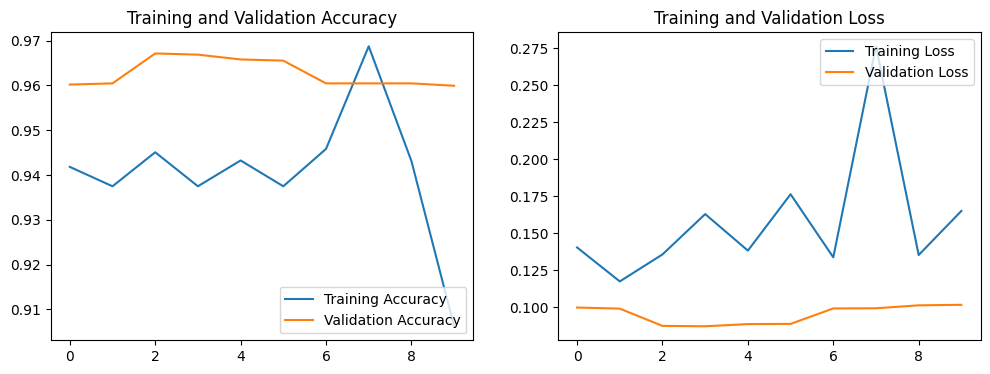

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

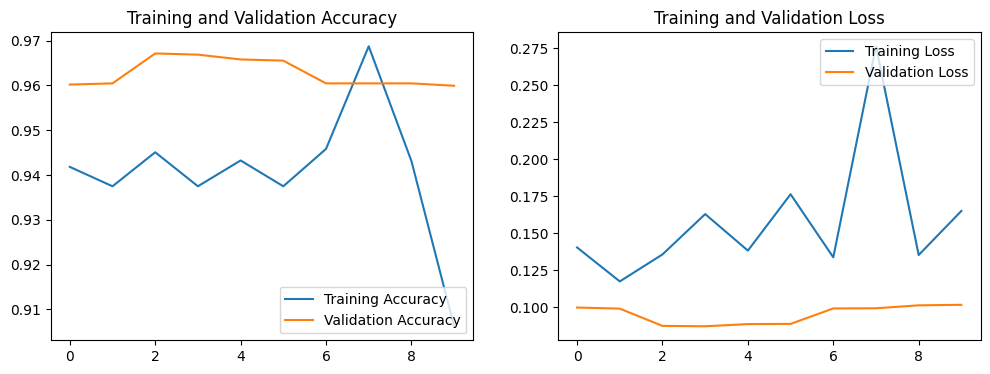

In [17]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Model Evaluation on Test Data

Evaluating model on test data...
114/117 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9511 - loss: 0.1326

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.9642 - loss: 0.0970
Test Loss: 0.0970
Test Accuracy: 0.9642
Generating predictions for test data...
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step

Confusion Matrix:


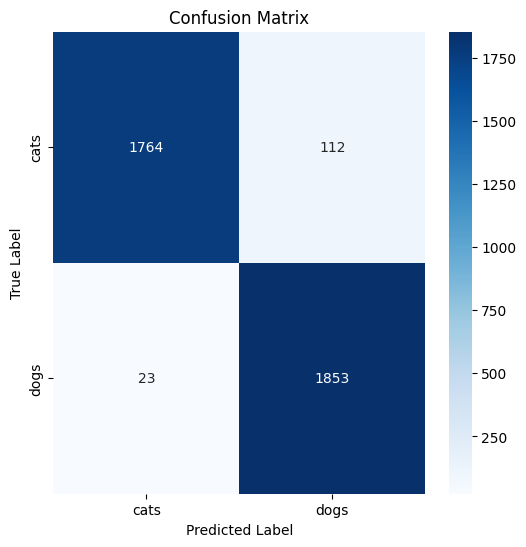


Classification Report:
              precision    recall  f1-score   support

        cats       0.99      0.94      0.96      1876
        dogs       0.94      0.99      0.96      1876

    accuracy                           0.96      3752
   macro avg       0.97      0.96      0.96      3752
weighted avg       0.97      0.96      0.96      3752


ROC-AUC Curve:


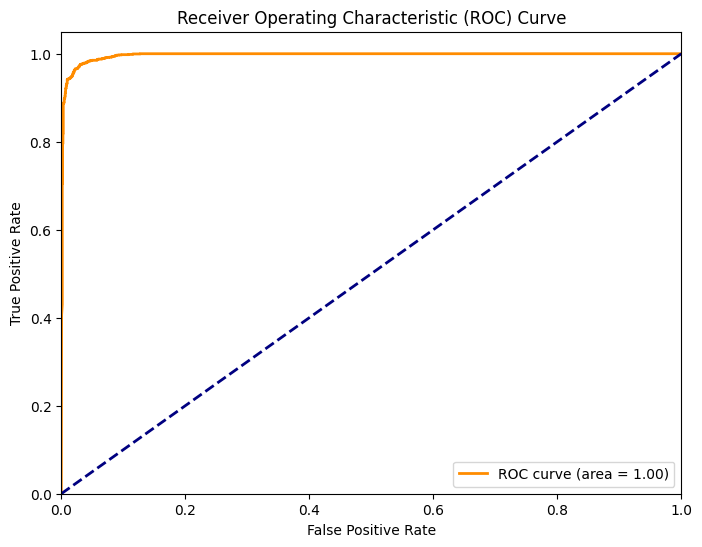

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import seaborn as sns # Import seaborn for heatmap

# Evaluate the model on the test data
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions for the test set
print("Generating predictions for test data...")
# Ensure test_generator is reset if it has been used before
test_generator.reset()
predictions = model.predict(test_generator)

# Convert probabilities to binary classes (0 or 1)
y_pred = (predictions > 0.5).astype(int)

# Get true labels
y_true = test_generator.classes

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ROC-AUC Curve
print("\nROC-AUC Curve:")
# For binary classification, roc_curve expects probabilities of the positive class
# If predictions is (N, 1), convert to (N,) for roc_curve
if predictions.shape[-1] == 1:
    y_pred_proba = predictions.ravel()
else:
    y_pred_proba = predictions[:, 1] # Assuming 1 is the positive class

fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()